# NYC Taxi Trip Data Analysis

## Objective
This project analyzes NYC taxi trip data to uncover patterns in trip demand, temporal trends, geographic hotspots, and tipping behavior.

## Dataset
- Source: NYC Taxi Data
- Size: ~83k trips
- Features: trip distance, fare, pickup/dropoff time, location, payment type, etc.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 #plot heatmap
import seaborn as sns


In [6]:
# read the data in the taxi_tripdata.csv file and stored in the df.
df = pd.read_csv('/Users/404ntots/Documents/nyc-taxi-project/data/raw/taxi_tripdata.csv', low_memory=False)

In [7]:
# show the first five row in the dataset
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,1.0,2021-07-01 00:30:52,2021-07-01 00:35:36,N,1.0,74,168,1.0,1.20,6.0,0.5,0.5,0.00,0.0,NaN,0.3,7.30,2.0,1.0,0.0
1,2.0,2021-07-01 00:25:36,2021-07-01 01:01:31,N,1.0,116,265,2.0,13.69,42.0,0.5,0.5,0.00,0.0,NaN,0.3,43.30,2.0,1.0,0.0
2,2.0,2021-07-01 00:05:58,2021-07-01 00:12:00,N,1.0,97,33,1.0,0.95,6.5,0.5,0.5,2.34,0.0,NaN,0.3,10.14,1.0,1.0,0.0
3,2.0,2021-07-01 00:41:40,2021-07-01 00:47:23,N,1.0,74,42,1.0,1.24,6.5,0.5,0.5,0.00,0.0,NaN,0.3,7.80,2.0,1.0,0.0
4,2.0,2021-07-01 00:51:32,2021-07-01 00:58:46,N,1.0,42,244,1.0,1.10,7.0,0.5,0.5,0.00,0.0,NaN,0.3,8.30,2.0,1.0,0.0


In [8]:
# show how many instances and variables we have
df.shape

(83691, 20)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83691 entries, 0 to 83690
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               51173 non-null  float64
 1   lpep_pickup_datetime   83691 non-null  str    
 2   lpep_dropoff_datetime  83691 non-null  str    
 3   store_and_fwd_flag     51173 non-null  str    
 4   RatecodeID             51173 non-null  float64
 5   PULocationID           83691 non-null  int64  
 6   DOLocationID           83691 non-null  int64  
 7   passenger_count        51173 non-null  float64
 8   trip_distance          83691 non-null  float64
 9   fare_amount            83691 non-null  float64
 10  extra                  83691 non-null  float64
 11  mta_tax                83691 non-null  float64
 12  tip_amount             83691 non-null  float64
 13  tolls_amount           83691 non-null  float64
 14  ehail_fee              0 non-null      float64
 15  improvement_s

In [10]:
# To see there are how many miss values in each row
df.isna().sum()

VendorID                 32518
lpep_pickup_datetime         0
lpep_dropoff_datetime        0
store_and_fwd_flag       32518
RatecodeID               32518
PULocationID                 0
DOLocationID                 0
passenger_count          32518
trip_distance                0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
ehail_fee                83691
improvement_surcharge        0
total_amount                 0
payment_type             32518
trip_type                32518
congestion_surcharge     32518
dtype: int64

In [11]:
# give the statistic value.
df.describe()

,VendorID,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,51173.000000,51173.000000,83691.000000,83691.000000,51173.000000,83691.000000,83691.000000,83691.000000,83691.000000,83691.000000,83691.000000,0.0,83691.000000,83691.000000,51173.000000,51173.000000,51173.000000
mean,1.851113,1.159244,108.362572,133.270005,1.307858,194.354699,20.388305,1.156707,0.293562,1.058618,0.624529,NaN,0.297745,24.204836,1.421726,1.034393,0.642815
std,0.355981,0.773260,70.370170,77.216791,0.984362,4405.549221,15.583552,1.367897,0.247773,2.368771,1.990481,NaN,0.031219,17.262183,0.511146,0.182239,1.164219
min,1.000000,1.000000,3.000000,1.000000,0.000000,0.000000,-150.000000,-4.500000,-0.500000,-1.140000,0.000000,NaN,-0.300000,-150.300000,1.000000,1.000000,-2.750000
25%,2.000000,1.000000,56.000000,69.000000,1.000000,1.350000,9.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.300000,11.760000,1.000000,1.000000,0.000000
50%,2.000000,1.000000,75.000000,132.000000,1.000000,2.760000,16.000000,0.500000,0.500000,0.000000,0.000000,NaN,0.300000,19.800000,1.000000,1.000000,0.000000
75%,2.000000,1.000000,166.000000,205.000000,1.000000,6.200000,26.830000,2.750000,0.500000,1.660000,0.000000,NaN,0.300000,31.300000,2.000000,1.000000,0.000000
max,2.000000,5.000000,265.000000,265.000000,32.000000,260517.930000,480.000000,8.250000,0.500000,87.710000,30.050000,NaN,0.300000,480.310000,5.000000,2.000000,2.750000


## Data Cleaning

In addition to removing invalid values (e.g., negative fares or zero distances), extreme outliers were filtered using domain-based thresholds.
Trips with unrealistic distance (>50 miles), duration (>180 minutes), or fare (>200 USD) were removed to improve data quality and prevent distortion in statistical summaries.

In [12]:
# 1. convert datetime columns
df["lpep_pickup_datetime"] = pd.to_datetime(df["lpep_pickup_datetime"])
df["lpep_dropoff_datetime"] = pd.to_datetime(df["lpep_dropoff_datetime"])

# 2. create time-based columns
df["pickup_hour"] = df["lpep_pickup_datetime"].dt.hour
df["pickup_weekday"] = df["lpep_pickup_datetime"].dt.day_name()

# 3. compute trip duration in minutes
df["trip_duration_min"] = (
    df["lpep_dropoff_datetime"] - df["lpep_pickup_datetime"]
).dt.total_seconds() / 60

# 4. check basic anomalies
print("trip_distance <= 0:", (df["trip_distance"] <= 0).sum())
print("trip_duration_min <= 0:", (df["trip_duration_min"] <= 0).sum())
print("fare_amount < 0:", (df["fare_amount"] < 0).sum())
print("total_amount < 0:", (df["total_amount"] < 0).sum())

# 5. remove invalid values
df_clean = df[
    (df["trip_distance"] > 0) &
    (df["trip_duration_min"] > 0) &
    (df["fare_amount"] >= 0) &
    (df["total_amount"] >= 0)
].copy()

# 6. remove extreme outliers
df_clean = df_clean[
    (df_clean["trip_distance"] < 50) &
    (df_clean["trip_duration_min"] < 180) &
    (df_clean["fare_amount"] < 200)
]

print("After advanced cleaning:", df_clean.shape)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

# 6. inspect cleaned summary
print(df_clean[["trip_distance", "trip_duration_min", "fare_amount", "total_amount"]].describe())

trip_distance <= 0: 3455
trip_duration_min <= 0: 82
fare_amount < 0: 145
total_amount < 0: 145
After advanced cleaning: (79607, 23)
Original shape: (83691, 23)
Cleaned shape: (79607, 23)
       trip_distance  trip_duration_min   fare_amount  total_amount
count   79607.000000       79607.000000  79607.000000  79607.000000
mean        4.946365          20.051807     20.456036     24.339265
std         5.283774          16.436840     15.332192     16.999332
min         0.010000           0.016667      0.000000      0.000000
25%         1.470000           8.950000      9.000000     11.800000
50%         2.900000          15.000000     16.000000     19.860000
75%         6.400000          26.000000     26.830000     31.310000
max        49.600000         178.266667    185.500000    207.480000


Thresholds were chosen based on realistic taxi trip ranges in NYC.
Trips longer than 50 miles or 3 hours are rare and likely represent data errors.

In [13]:
print("=== BEFORE CLEANING ===")
print(df[["trip_distance", "trip_duration_min", "fare_amount"]].describe())

print("\n=== AFTER CLEANING ===")
print(df_clean[["trip_distance", "trip_duration_min", "fare_amount"]].describe())

=== BEFORE CLEANING ===
       trip_distance  trip_duration_min   fare_amount
count   83691.000000       83691.000000  83691.000000
mean      194.354699          24.438299     20.388305
std      4405.549221          77.464005     15.583552
min         0.000000           0.000000   -150.000000
25%         1.350000           8.741667      9.000000
50%         2.760000          15.000000     16.000000
75%         6.200000          26.400000     26.830000
max    260517.930000        1438.766667    480.000000

=== AFTER CLEANING ===
       trip_distance  trip_duration_min   fare_amount
count   79607.000000       79607.000000  79607.000000
mean        4.946365          20.051807     20.456036
std         5.283774          16.436840     15.332192
min         0.010000           0.016667      0.000000
25%         1.470000           8.950000      9.000000
50%         2.900000          15.000000     16.000000
75%         6.400000          26.000000     26.830000
max        49.600000         178.2

Data cleaning significantly reduced extreme values and stabilized key metrics such as mean trip distance and duration.

### Number of Trips by Pickup Hour 

In [14]:
# get the showup times by each hour, and sorted by 0, 1, 2...
hour_counts = df_clean['pickup_hour'].value_counts().sort_index()

hour_counts

pickup_hour
0      981
1      619
2      402
3      340
4      459
5      903
6     1836
7     3176
8     4786
9     5540
10    5768
11    5769
12    5480
13    5225
14    5312
15    5435
16    5022
17    4948
18    4992
19    4115
20    2714
21    2275
22    1883
23    1627
Name: count, dtype: int64

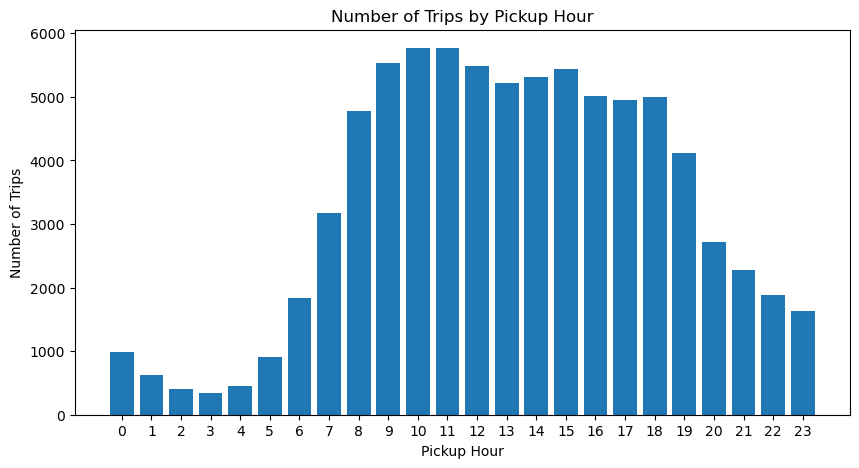

In [15]:
#generate bar chart
plt.figure(figsize=(10,5))
plt.bar(hour_counts.index, hour_counts.values)
plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.title("Number of Trips by Pickup Hour")
plt.xticks(range(24))
plt.show()


In [16]:
print("Busiest hour:", hour_counts.idxmax())
print("Max trips in an hour:", hour_counts.max())
print(hour_counts.sort_values(ascending=False).head())

Busiest hour: 11
Max trips in an hour: 5769
pickup_hour
11    5769
10    5768
9     5540
12    5480
15    5435
Name: count, dtype: int64


### Observation: Trips by Pickup Hour. 
Trip demand is not evenly distributed across the day.  
The busiest pickup hour is **11 AM**, with **5769 trips**, followed closely by **10 AM** and **9 AM**.  
Demand starts to rise quickly after **6 AM**, remains high from late morning through the afternoon, and then declines after **8 PM**.  
Late-night and early-morning hours show substantially lower trip volumes.

### Insight

Taxi demand peaks around 10–11 AM, indicating strong mid-morning usage, likely driven by commuting and business activities.

### Trips by weekdays

In [17]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_counts = df_clean["pickup_weekday"].value_counts().reindex(weekday_order)
weekday_counts

pickup_weekday
Monday        9843
Tuesday      10331
Wednesday    11172
Thursday     14128
Friday       14292
Saturday     12306
Sunday        7535
Name: count, dtype: int64

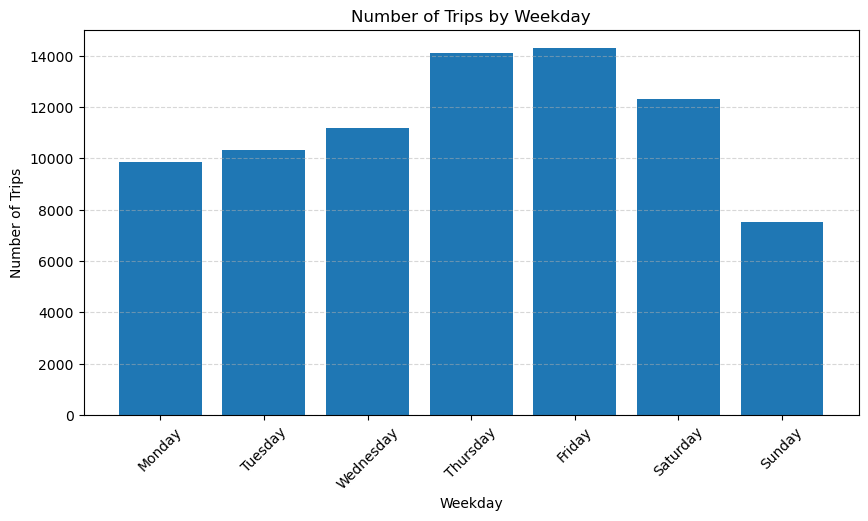

In [18]:
plt.figure(figsize=(10, 5))
plt.bar(weekday_counts.index, weekday_counts.values)
plt.xlabel("Weekday")
plt.ylabel("Number of Trips")
plt.title("Number of Trips by Weekday")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [19]:
print("Busiest weekday:", weekday_counts.idxmax())
print("Max trips on a weekday:", weekday_counts.max())
print(weekday_counts.sort_values(ascending=False))

Busiest weekday: Friday
Max trips on a weekday: 14292
pickup_weekday
Friday       14292
Thursday     14128
Saturday     12306
Wednesday    11172
Tuesday      10331
Monday        9843
Sunday        7535
Name: count, dtype: int64


### Observation: Trips by Weekday

Trip volume varies noticeably across the week rather than remaining constant.

The busiest weekday is **Friday**, with **14,292 trips**, followed closely by **Thursday** with **14,128 trips**.

Trip demand generally increases from **Monday to Friday**, remains relatively high on **Saturday**, and then drops to its lowest level on **Sunday**.

This pattern suggests that taxi usage is stronger toward the end of the workweek and weaker on Sundays.

### Insight

Taxi demand is highest toward the end of the workweek, peaking on Friday. This suggests increased travel activity before the weekend, while Sunday shows the lowest demand.

### Top Pickup Zone

In [20]:
pickup_zone_counts = df_clean["PULocationID"].value_counts().head(10)
pickup_zone_counts

PULocationID
74     8604
75     7553
41     4669
42     3100
95     2391
166    2340
244    2225
7      1748
97     1716
65     1512
Name: count, dtype: int64

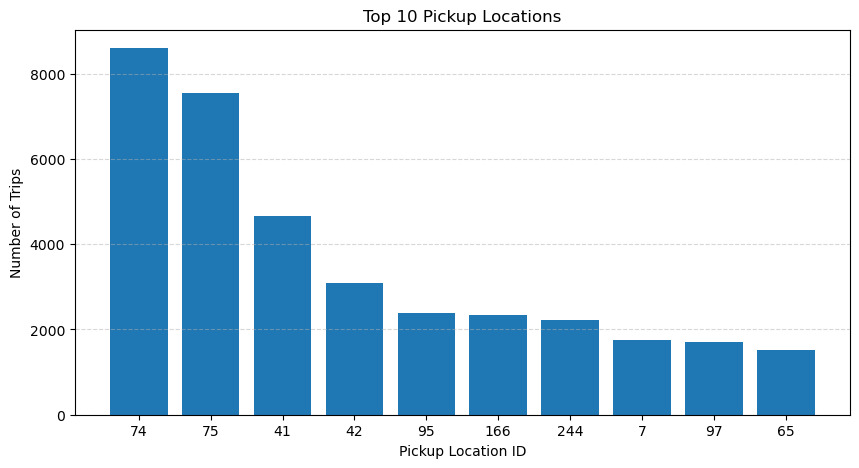

In [21]:
plt.figure(figsize=(10, 5))
plt.bar(pickup_zone_counts.index.astype(str), pickup_zone_counts.values)
plt.xlabel("Pickup Location ID")
plt.ylabel("Number of Trips")
plt.title("Top 10 Pickup Locations")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Observation: Top Pickup Locations

Trip demand is highly concentrated in a small number of pickup zones.

The most active pickup locations (e.g., Location IDs 74 and 75) have significantly higher trip volumes compared to others, suggesting strong geographic clustering of taxi demand.

This indicates that certain areas serve as major transportation hubs, likely due to high population density, business activity, or proximity to transit centers.

### Note: 
PULocationID represents geographic taxi zones in NYC. While IDs themselves are numeric, they correspond to specific areas such as business districts, airports, or residential zones.

In [22]:
dropoff_zone_counts = df_clean["DOLocationID"].value_counts().head(10)
dropoff_zone_counts


DOLocationID
74     3548
75     3025
42     2815
41     2471
236    1677
238    1533
166    1408
244    1221
263    1211
151    1126
Name: count, dtype: int64

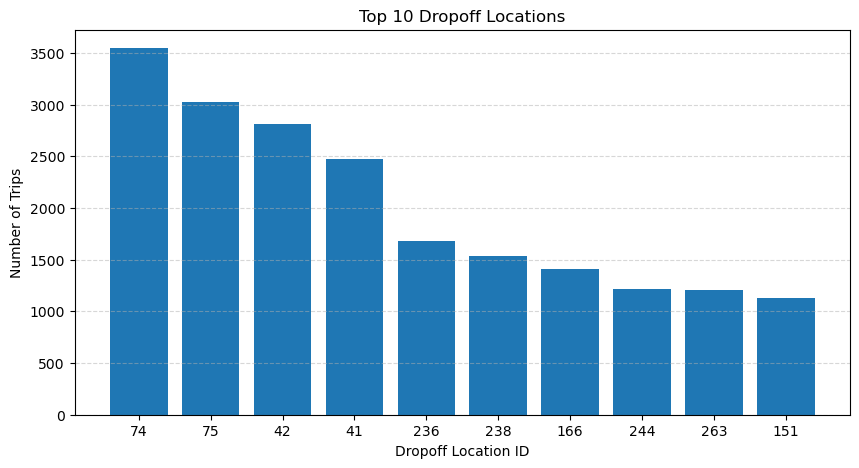

In [23]:
plt.figure(figsize=(10,5))
plt.bar(dropoff_zone_counts.index.astype(str), dropoff_zone_counts.values)
plt.xlabel("Dropoff Location ID")
plt.ylabel("Number of Trips")
plt.title("Top 10 Dropoff Locations")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Observation: Dropoff Locations. 
Dropoff locations exhibit a similar concentration pattern, with a small number of zones accounting for a large share of total trips.

This indicates that travel demand is not evenly distributed across the city, but instead focused on specific high-traffic areas.

### Comparison Insight
There is likely overlap between top pickup and dropoff locations, suggesting the presence of key travel corridors within the city.

These corridors may represent common commuting routes, such as between residential areas and business districts or major transit hubs.

### Business Insight
Understanding high-demand pickup and dropoff zones can help:
- Optimize taxi supply and reduce passenger wait times
- Improve driver allocation and routing efficiency
- Support urban transportation planning and infrastructure decisions

### Payment Type

In [24]:
# 1. count
payment_counts = df_clean["payment_type"].value_counts()

# mapping to readable names
payment_map = {
    1.0: "Credit card",
    2.0: "Cash",
    3.0: "No charge",
    4.0: "Dispute",
    5.0: "Unknown",
    6.0: "Voided trip"
}

payment_counts_named = payment_counts.copy()
payment_counts_named.index = payment_counts_named.index.map(payment_map)

# sort
payment_counts_named = payment_counts_named.sort_values(ascending=False)

# 2. percentage
payment_share = df_clean["payment_type"].value_counts(normalize=True) * 100
payment_share_named = payment_share.copy()
payment_share_named.index = payment_share_named.index.map(payment_map)
payment_share_named = payment_share_named.round(1)

# 3. print clean results
print("Payment Counts:")
print(payment_counts_named)

print("\nPayment Share (%):")
print(payment_share_named)

print("\nMost common payment type:", payment_counts_named.idxmax())
print("Max trips:", payment_counts_named.max())

Payment Counts:
payment_type
Credit card    27791
Cash           20018
No charge        155
Dispute           20
Unknown            1
Name: count, dtype: int64

Payment Share (%):
payment_type
Credit card    57.9
Cash           41.7
No charge       0.3
Dispute         0.0
Unknown         0.0
Name: proportion, dtype: float64

Most common payment type: Credit card
Max trips: 27791


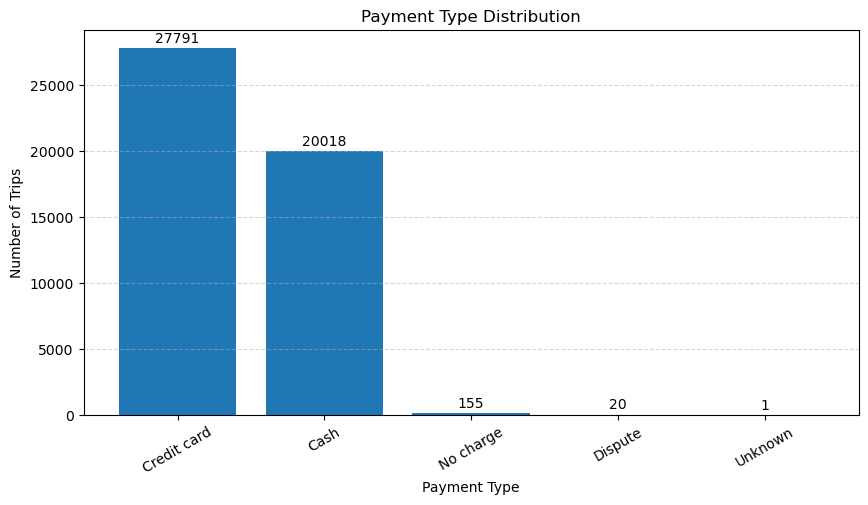

In [25]:
plt.figure(figsize=(10,5))

bars = plt.bar(payment_counts_named.index, payment_counts_named.values)

# add value labels (VERY IMPORTANT)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 200,
             f'{int(yval)}', ha='center', va='bottom')

plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")
plt.title("Payment Type Distribution")

plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Observation: Payment Type Distribution

Payment behavior is highly concentrated in two primary methods: credit card and cash.

Credit card is the most common payment type with **27,791 trips**, followed by cash with **20,018 trips**. In relative terms, credit card accounts for approximately 58% of all trips, while cash represents about **42%**.

All other payment types are negligible, each contributing less than **1%** of total trips.

This distribution highlights the dominance of digital payments in taxi transactions and suggests that most customer behavior can be effectively analyzed using these two primary payment methods.


### Insight

The dominance of credit card payments enables more reliable tracking of tipping behavior, as cash tips are often not recorded.

This provides a more accurate basis for analyzing customer tipping patterns and driver earnings.

Additionally, the high share of digital payments suggests opportunities for data-driven pricing strategies and customer behavior analysis.

### Tip Percentage

In [26]:
df_clean["tip_pct"] = np.where(df_clean['fare_amount'] > 0,
                                df_clean['tip_amount'] / df_clean['fare_amount'],
                                np.nan)

In [27]:
credit_card_trips = df_clean[df_clean["payment_type"] == 1.0].copy()
credit_card_trips["tip_pct"].describe()

count    27789.000000
mean         0.202827
std          0.308351
min          0.000000
25%          0.090909
50%          0.221333
75%          0.271000
max         18.400000
Name: tip_pct, dtype: float64

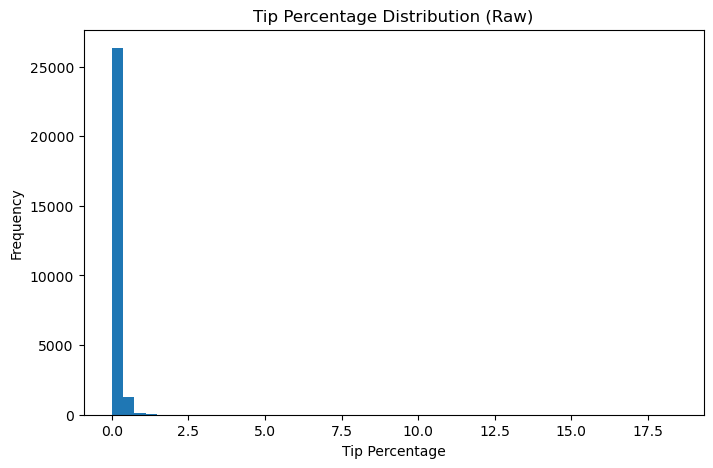

In [28]:
plt.figure(figsize=(8,5))
plt.hist(credit_card_trips["tip_pct"], bins=50)
plt.xlabel("Tip Percentage")
plt.ylabel("Frequency")
plt.title("Tip Percentage Distribution (Raw)")
plt.show()

In [29]:
tip_filtered = credit_card_trips[
    (credit_card_trips["tip_pct"] >= 0) &
    (credit_card_trips["tip_pct"] <= 1)
]

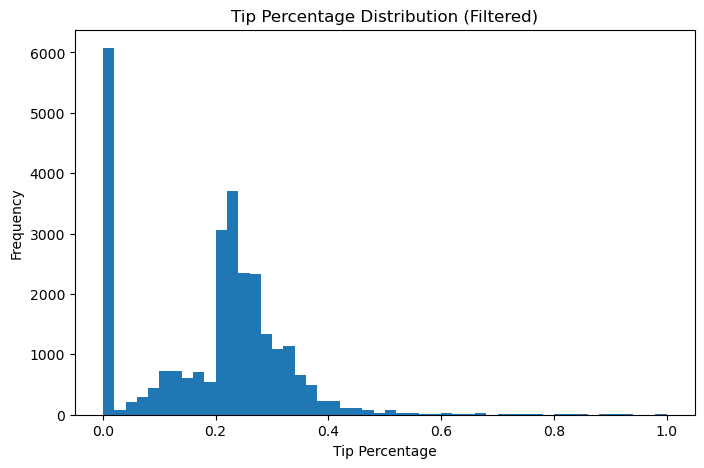

In [30]:
plt.figure(figsize=(8,5))
plt.hist(tip_filtered["tip_pct"], bins=50)
plt.xlabel("Tip Percentage")
plt.ylabel("Frequency")
plt.title("Tip Percentage Distribution (Filtered)")
plt.show()

### Observation: Tip Percentage Distribution (Credit Card)  
Before analysis, extreme values (e.g., tip percentage greater than 100%) were removed, as they likely represent data entry errors or anomalies.

Tip percentages are not evenly distributed and show a clear concentration within a specific range.

After removing extreme outliers, most trips have tip percentages between **10% and 30%**, with a noticeable peak around **15%–25%**.

A large number of trips also have **zero tip**, indicating that a significant portion of riders do not tip at all.

The distribution is right-skewed, with a long tail extending toward higher tip percentages, suggesting that while most riders follow common tipping norms, a small number of trips include unusually high tips.

Overall, tipping behavior appears to follow consistent social norms, with most riders clustering around standard tipping percentages.

### Business Insight

The strong clustering of tip percentages around 15%–25% suggests that most riders follow standard tipping norms, which can be useful for revenue forecasting and driver income modeling.

### Fare vs Distance Analysis

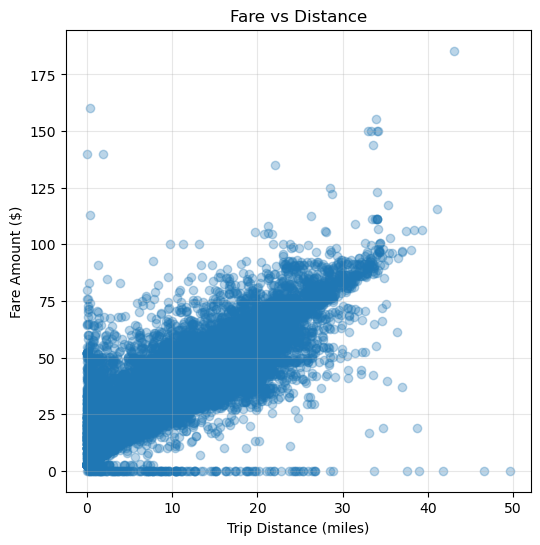

In [31]:
plt.figure(figsize=(6,6))
plt.scatter(df_clean["trip_distance"], df_clean["fare_amount"], alpha=0.3)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.title("Fare vs Distance")
plt.grid(alpha=0.3)
plt.show()

### Observation: Fare vs Distance
Fare amount shows a strong positive relationship with trip distance, indicating that pricing is largely distance-based.

However, variability increases for longer trips, suggesting the influence of additional factors such as traffic conditions, route variation, and surcharges.


### Heatmap: Hour × weekday

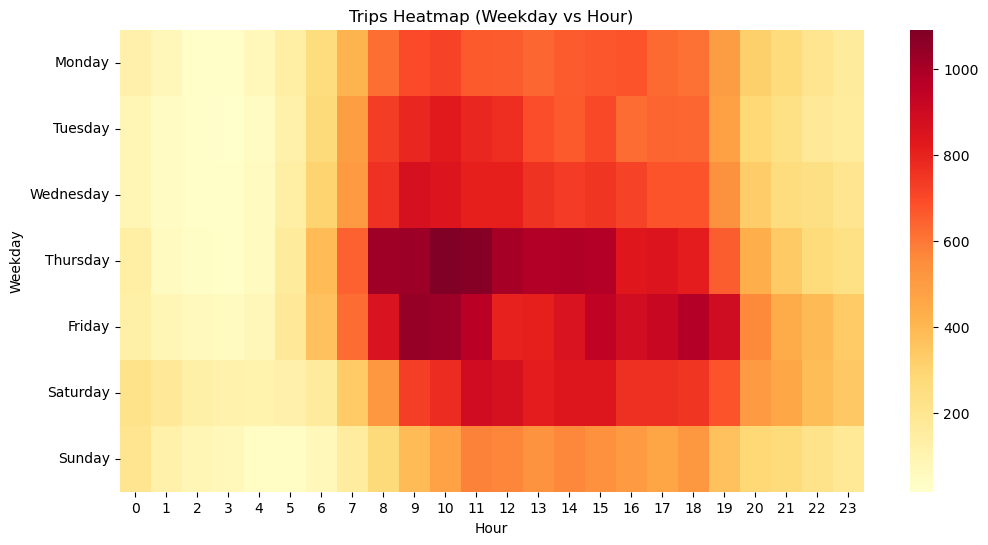

In [32]:
# create pivot table
heatmap_data = df_clean.pivot_table(
    index="pickup_weekday",
    columns="pickup_hour",
    values="trip_distance",
    aggfunc="count"
)

# reorder weekdays
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = heatmap_data.reindex(weekday_order)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="YlOrRd")
plt.title("Trips Heatmap (Weekday vs Hour)")
plt.xlabel("Hour")
plt.ylabel("Weekday")
plt.show()

### Observation: Trips Heatmap (Weekday vs Hour)
Taxi demand varies significantly across both time of day and day of week.

Peak demand is concentrated during weekday daytime hours, especially late morning to afternoon.

Friday shows consistently higher activity, while Sunday remains the lowest.

This confirms that taxi usage depends on both hour and weekday simultaneously.

# Limitations

This analysis has several limitations:

- Location IDs were not mapped to actual geographic zone names, which limits interpretability.
- Threshold-based filtering may remove some valid extreme trips.
- The dataset represents a subset of NYC taxi trips and may not capture all citywide patterns.

Future work could include geographic visualization, demand forecasting, and deeper analysis of fare structure.

# Conclusion

This analysis reveals clear patterns in NYC taxi usage:

- Demand is highest during mid-morning hours and declines at night
- Trip volume increases toward the end of the workweek
- Certain pickup locations dominate trip volume
- Credit card is the dominant payment method
- Tipping behavior follows consistent social norms, with most tips between 15%–25%

These insights can help optimize taxi operations, pricing strategies, and driver allocation.